# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


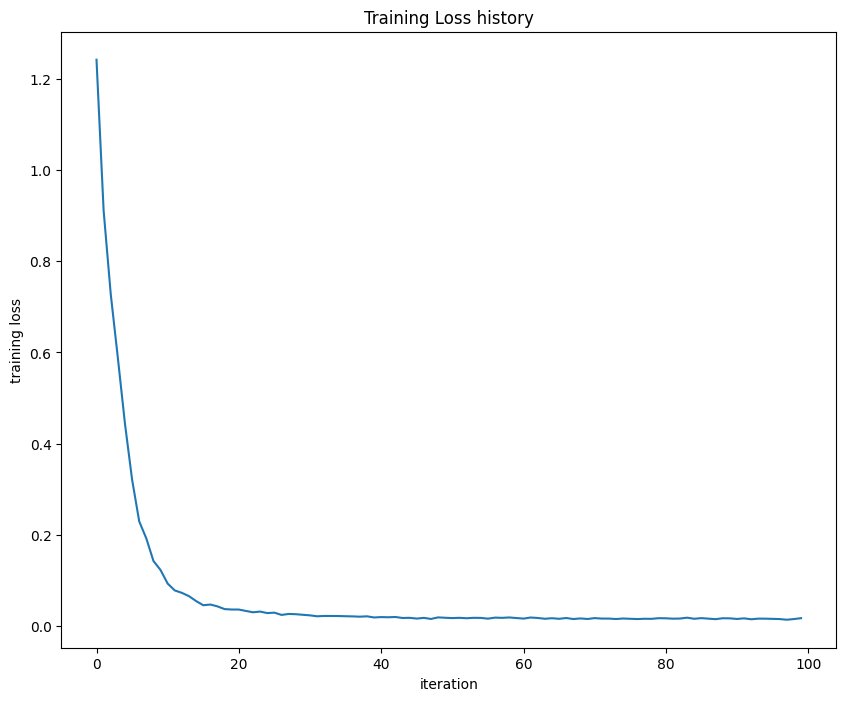

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 48000
mask = list(range(num_training))
X_train_tln = X_train[mask]
y_train_tln = y_train[mask]

num_validation = 2000
mask = list(range(num_training, num_training + num_validation))
X_val_tln = X_train[mask]
y_val_tln = y_train[mask]

num_test = 10000
mask = list(range(num_test))
X_test_tln = X_test[mask]
y_test_tln = y_test[mask]

X_train_tln = np.reshape(X_train_tln, (X_train_tln.shape[0], -1))
X_val_tln = np.reshape(X_val_tln, (X_val_tln.shape[0], -1))
X_test_tln = np.reshape(X_test_tln, (X_test_tln.shape[0], -1))

mean_image = np.mean(X_train_tln, axis=0)

X_train_tln -= mean_image
X_val_tln -= mean_image
X_test_tln -= mean_image

print('Training data shape: ', X_train_tln.shape)
print('Training labels shape: ', y_train_tln.shape)
print('Validation data shape: ', X_val_tln.shape)
print('Validation labels shape: ', y_val_tln.shape)
print('Test data shape: ', X_test_tln.shape)
print('Test labels shape: ', y_test_tln.shape)

Training data shape:  (48000, 3072)
Training labels shape:  (48000,)
Validation data shape:  (2000, 3072)
Validation labels shape:  (2000,)
Test data shape:  (10000, 3072)
Test labels shape:  (10000,)


In [8]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train_tln, y_train_tln, X_val_tln, y_val_tln,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val_tln) == y_val_tln).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302955
iteration 100 / 1000: loss 2.302545
iteration 200 / 1000: loss 2.298800
iteration 300 / 1000: loss 2.264437
iteration 400 / 1000: loss 2.168962
iteration 500 / 1000: loss 2.098591
iteration 600 / 1000: loss 2.033553
iteration 700 / 1000: loss 2.067266
iteration 800 / 1000: loss 2.008133
iteration 900 / 1000: loss 2.007479
Validation accuracy:  0.286


In [9]:
best_net = None
best_stats = None
best_val = -1
results = {}

hidden_sizes = [50, 100, 150]
learning_rates = [5e-4, 1e-3, 1.5e-3]
regularization_strengths = [0.1, 0.25, 0.5]

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularization_strengths:
            net = TwoLayerNet(input_size, hs, num_classes)
            stats = net.train(X_train_tln, y_train_tln, X_val_tln, y_val_tln,
                              num_iters=2000, batch_size=400,
                              learning_rate=lr, learning_rate_decay=0.95,
                              reg=reg, verbose=False)
            val_acc = (net.predict(X_val_tln) == y_val_tln).mean()
            print(f'hs: {hs}, lr: {lr}, reg: {reg} => val_acc: {val_acc}')
            if val_acc > best_val:
                best_val = val_acc
                best_net = net
                best_stats = stats

print(f'\nЛучшая точность на валидации: {best_val}')
test_acc = (best_net.predict(X_test_tln) == y_test_tln).mean()
print(f'Точность на тестовой выборке: {test_acc}')

hs: 50, lr: 0.0005, reg: 0.1 => val_acc: 0.467
hs: 50, lr: 0.0005, reg: 0.25 => val_acc: 0.4645
hs: 50, lr: 0.0005, reg: 0.5 => val_acc: 0.457
hs: 50, lr: 0.001, reg: 0.1 => val_acc: 0.49
hs: 50, lr: 0.001, reg: 0.25 => val_acc: 0.5
hs: 50, lr: 0.001, reg: 0.5 => val_acc: 0.491
hs: 50, lr: 0.0015, reg: 0.1 => val_acc: 0.504
hs: 50, lr: 0.0015, reg: 0.25 => val_acc: 0.4935
hs: 50, lr: 0.0015, reg: 0.5 => val_acc: 0.49
hs: 100, lr: 0.0005, reg: 0.1 => val_acc: 0.475
hs: 100, lr: 0.0005, reg: 0.25 => val_acc: 0.468
hs: 100, lr: 0.0005, reg: 0.5 => val_acc: 0.4675
hs: 100, lr: 0.001, reg: 0.1 => val_acc: 0.511
hs: 100, lr: 0.001, reg: 0.25 => val_acc: 0.5125
hs: 100, lr: 0.001, reg: 0.5 => val_acc: 0.5045
hs: 100, lr: 0.0015, reg: 0.1 => val_acc: 0.52
hs: 100, lr: 0.0015, reg: 0.25 => val_acc: 0.52
hs: 100, lr: 0.0015, reg: 0.5 => val_acc: 0.5175
hs: 150, lr: 0.0005, reg: 0.1 => val_acc: 0.4815
hs: 150, lr: 0.0005, reg: 0.25 => val_acc: 0.478
hs: 150, lr: 0.0005, reg: 0.5 => val_acc: 0.480

Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

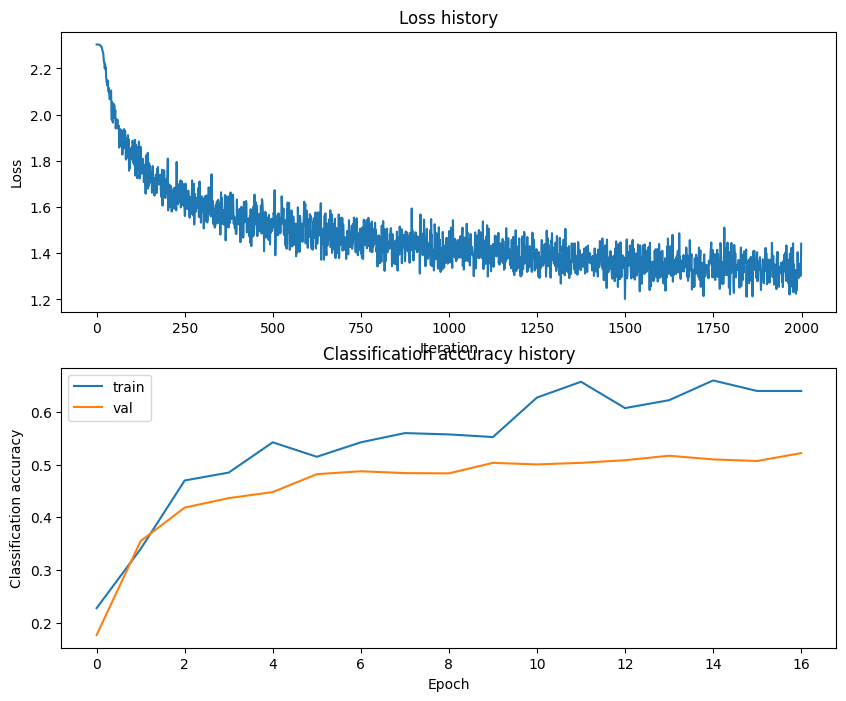

In [10]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

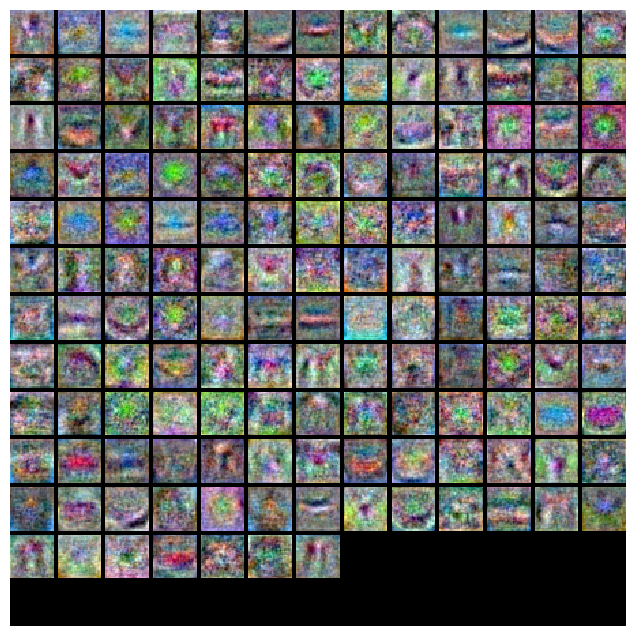

In [11]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(best_net)

Сделайте выводы по результатам работы. 

<span> X, y — обучающие данные и метки классов. <br>
X_val, y_val — валидационная выборка. Нужна, чтобы оценивать точность в процессе обучения. <br>
learning_rate — скорость обучения. <br>
learning_rate_decay — затухание скорости обучения. <br>
reg — сила регуляризации. Коэффициент L2-регуляризации, который штрафует модель за слишком большие значения весов W. <br>
num_iters — количество итераций, число шагов градиентного спуска. <br>
batch_size — размер батча, количество примеров, которые сеть просматривает за одну итерацию. <br>
verbose — флаг, отвечающий за вывод логов. </span>


В ходе выполнения лабораторной работы была реализована и исследована двухслойная полносвязная нейронная сеть, итоговая точность которой на тестовой выборке составила 51.62%, что демонстрирует скачок в производительности по сравнению с методами из предыдущей работы: классификатор k-NN достигал 28% точности, а линейный классификатор (SVM) показал результат около 35.5%. Внедрение скрытого слоя размерностью в 150 нейронов с нелинейной функцией активации ReLU позволило нейронной сети аппроксимировать гораздо более сложные зависимости, что увеличило точность более чем на 15% относительно линейной модели. Проведенная настройка гиперпараметров показала, что для данной архитектуры критически важен баланс между скоростью обучения и регуляризацией. Минимальный разрыв между валидационной точностью (52.7%) и тестовой (51.62%) подтверждает, что выбранные параметры регуляризации эффективно предотвратили переобучение.